# Conversational AI - Group 129
**Problem Statement-2:** Study of Embedding Models and Approximate Nearest Neighbor Search - Semantic Quality vs Search Efficiency

### **Group 129**

| Item | Details |
|---|---|
| **Course** | AIMLCZG521 Conversational AI |
| **Group ID** | Group 129 |
| **Dataset** | `allenai/sciq` (10,000 passages, 500 queries) |
| **Models Evaluated** | `all-MiniLM-L6-v2` (384-dim, Mean) & `multi-qa-mpnet-base-dot-v1` (768-dim, CLS) |
| **ANN Indexes** | HNSW (Graph-based) & IVF (Partition-based) via FAISS |
| **Date** | August 2026 |

## Student Details

| Name | BITS ID | Email |
|---|---|---|
| Pushadapu Sanjay Kumar | 2025ae05898 | 2025ae05898@wilp.bits-pilani.ac.in |
| B Devchandraaj | 2025ae05469 | 2025ae05469@wilp.bits-pilani.ac.in |
| Gourob Nandi | 2025ae05503 | 2025ae05503@wilp.bits-pilani.ac.in |
| Anirudh Anand | 2025ae05576 | 2025ae05576@wilp.bits-pilani.ac.in |


The students worked as a group on this assignment and divided the work by task so that each member contributed to a different part of the study.

## Group Contributions

| Student | Contribution area | Specific contribution |
|---|---|---|
| Anirudh Anand | T1 Corpus/Query prep, T2 Embedding + Pooling | SciQ dataset loading, extraction, and embedding generation (M1: T1, T2) |
| B Devchandraaj | T3 Metric Comparison, T4 Exact kNN Baseline | Mathematical metric definitions, normalization analysis, exact kNN baseline (M2: T3, T4) |
| Pushadapu Sanjay Kumar | T5 HNSW vs IVF, T6 Trade-Off Analysis | FAISS HNSW & IVF index construction, hyperparameter sweeps (M3: T5, T6) |
| Gourob Nandi | T7 Qualitative Analysis, T8 Final Recommendation | Qualitative comparisons, difference classification, deployment architecture (M4: T7, T8) |

In [1]:
# Auto-install missing packages
import subprocess, sys, importlib.util

REQUIRED_PACKAGES = {
    "datasets": "datasets",
    "sentence_transformers": "sentence-transformers",
    "faiss": "faiss-cpu",
    "matplotlib": "matplotlib",
    "pandas": "pandas",
    "numpy": "numpy",
    "torch": "torch"
}

missing = [pip_name for mod_name, pip_name in REQUIRED_PACKAGES.items() if importlib.util.find_spec(mod_name) is None]
if missing:
    print(f"Installing missing packages: {', '.join(missing)}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("Installation complete.")
else:
    print("All required packages are available.")

All required packages are available.


In [2]:
# Global Configuration & Paths
import os, json, time, random
import numpy as np
import pandas as pd

# Fixed seed for reproducibility
RANDOM_SEED = 129
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Directory Setup
DATA_DIR    = "data/raw_sciq"
RESULTS_DIR = "data/results_sciq"
FIGURE_DIR  = "data/figures_sciq"

for d in [DATA_DIR, RESULTS_DIR, FIGURE_DIR]:
    os.makedirs(d, exist_ok=True)

# Dataset Targets
CORPUS_SIZE = 10000
QUERY_SIZE  = 500

# Model Specifications
MODEL_SPECS = {
    "all-MiniLM-L6-v2": {
        "architecture": "MiniLM-L6 (6 layers, 384-dim)",
        "dim": 384,
        "max_seq_length": 256,
        "pooling": "Mean Pooling",
        "training_objective": "Knowledge Distillation + Contrastive Fine-tuning on 1B+ sentence pairs"
    },
    "multi-qa-mpnet-base-dot-v1": {
        "architecture": "MPNet-Base (12 layers, 768-dim)",
        "dim": 768,
        "max_seq_length": 512,
        "pooling": "CLS Pooling",
        "training_objective": "Masked & Permuted LM + Contrastive Fine-tuning on 215M QA pairs"
    }
}

print("Configuration loaded. Data directories initialized.")

Configuration loaded. Data directories initialized.


## Module 1

## Task 1: Corpus and Query Dataset Preparation (0.5 Marks)

### Dataset Selection: SciQ (`allenai/sciq`)
We select the **SciQ dataset** curated by Allen Institute for AI (Welbl et al., 2017). 

**Why SciQ is appropriate for Semantic Retrieval Evaluation:**
1. **Natural Language Information Need:** Each query is a real multiple-choice science exam question (e.g., *"What is the process by which water vapor turns into liquid?"*).
2. **Objective Ground-Truth Alignment:** Every question is accompanied by an authoritative `support` text passage containing the scientific facts necessary to answer it.This forms our deterministic **Qrels** (Query Relevance) mapping.
3. **Challenging Lexical-Semantic Gap:** Scientific concepts frequently require reasoning across synonyms and technical descriptions rather than pure keyword matching.
4. **Scale & Distractors:** We extract 500 verified queries and pad the corpus with unique supporting passages to build a robust **10,000-document knowledge corpus**, well exceeding the 1,000-passage minimum requirement.

In [3]:
# Task 1 — Load SciQ dataset, construct 10k corpus, 500 queries, and Qrels mapping
from datasets import load_dataset

LOCAL_CORPUS  = os.path.join(DATA_DIR, "corpus_sciq.parquet")
LOCAL_QUERIES = os.path.join(DATA_DIR, "queries_sciq.parquet")
LOCAL_QRELS   = os.path.join(DATA_DIR, "qrels_sciq.parquet")
FORCE_RELOAD  = False  # Set to True to re-download from HuggingFace

if not FORCE_RELOAD and all(os.path.exists(p) for p in [LOCAL_CORPUS, LOCAL_QUERIES, LOCAL_QRELS]):
    corpus_df  = pd.read_parquet(LOCAL_CORPUS)
    queries_df = pd.read_parquet(LOCAL_QUERIES)
    qrels_df   = pd.read_parquet(LOCAL_QRELS)
    print(f"[Cache] Loaded from parquet: {len(corpus_df)} docs, {len(queries_df)} queries, {len(qrels_df)} qrels.")
else:
    print("Loading allenai/sciq dataset from HuggingFace...")
    dataset = load_dataset("allenai/sciq", split="train")
    
    corpus_passages = []
    queries_list    = []
    qrels_list      = []
    seen_supports   = set()
    
    # 1. Collect 500 unique queries and their direct supporting documents
    for row in dataset:
        support  = row["support"].strip()
        question = row["question"].strip()
        if support and question and support not in seen_supports:
            doc_id = f"doc_{len(corpus_passages):05d}"
            qid    = f"q_{len(queries_list):04d}"
            
            corpus_passages.append({"doc_id": doc_id, "passage": support})
            seen_supports.add(support)
            
            queries_list.append({"query_id": qid, "text": question})
            qrels_list.append({"query_id": qid, "doc_id": doc_id, "score": 1})
            
            if len(queries_list) == QUERY_SIZE:
                break
                
    # 2. Add distractor passages from validation/test/train until corpus hits 10,000
    for split_name in ["train", "validation", "test"]:
        split_data = load_dataset("allenai/sciq", split=split_name)
        for row in split_data:
            support = row["support"].strip()
            if support and support not in seen_supports:
                doc_id = f"doc_{len(corpus_passages):05d}"
                corpus_passages.append({"doc_id": doc_id, "passage": support})
                seen_supports.add(support)
                if len(corpus_passages) == CORPUS_SIZE:
                    break
        if len(corpus_passages) == CORPUS_SIZE:
            break
            
    corpus_df  = pd.DataFrame(corpus_passages)
    queries_df = pd.DataFrame(queries_list)
    qrels_df   = pd.DataFrame(qrels_list)
    
    # Save to Parquet
    corpus_df.to_parquet(LOCAL_CORPUS, index=False)
    queries_df.to_parquet(LOCAL_QUERIES, index=False)
    qrels_df.to_parquet(LOCAL_QRELS, index=False)
    print(f"[Created] Built & Saved: {len(corpus_df)} docs, {len(queries_df)} queries, {len(qrels_df)} qrels.")

[Cache] Loaded from parquet: 10000 docs, 500 queries, 500 qrels.


In [4]:
# Task 1 — Inspect Schema & Sample Records
import textwrap

print(f"-" * 60)
print(f"CORPUS SCHEMA (10,000 passages)")
print(f"-" * 60)
print(corpus_df.info())
print(f"--- Sample Document (doc_id={corpus_df.iloc[0]['doc_id']}): ---")
print(textwrap.fill(corpus_df.iloc[0]['passage'][:250] + "...", width=75))

print(f"\n" + "-" * 60)
print(f"QUERIES SCHEMA (500 queries)")
print(f"-" * 60)
print(queries_df.info())
print(f"Sample Query (query_id={queries_df.iloc[0]['query_id']}):")
print(f"  {queries_df.iloc[0]['text']}")

print("" + "-" * 60)
print("QRELS GROUND TRUTH SCHEMA (Relevance Mapping)")
print("-" * 60)
print(qrels_df.head())

------------------------------------------------------------
CORPUS SCHEMA (10,000 passages)
------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   doc_id   10000 non-null  str  
 1   passage  10000 non-null  str  
dtypes: str(2)
memory usage: 4.7 MB
None
--- Sample Document (doc_id=doc_00000): ---
Mesophiles grow best in moderate temperature, typically between 25°C and
40°C (77°F and 104°F). Mesophiles are often found living in or on the
bodies of humans or other animals. The optimal growth temperature of many
pathogenic mesophiles is 37°C (98...

------------------------------------------------------------
QUERIES SCHEMA (500 queries)
------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column    Non-Nul

In [5]:
# Task 1 Validation
assert len(corpus_df) == 10000, f"GATE FAIL: corpus has {len(corpus_df)} docs, expected 10,000"
assert len(queries_df) == 500, f"GATE FAIL: queries has {len(queries_df)}, expected 500"
assert len(qrels_df) >= 500, f"GATE FAIL: qrels has {len(qrels_df)} entries, expected >= 500"

assert "passage" in corpus_df.columns, "GATE FAIL: 'passage' column missing in corpus_df"
assert "text" in queries_df.columns, "GATE FAIL: 'text' column missing in queries_df"
assert set(qrels_df["query_id"]).issubset(set(queries_df["query_id"])), "GATE FAIL: Orphaned query IDs in qrels"
assert set(qrels_df["doc_id"]).issubset(set(corpus_df["doc_id"])), "GATE FAIL: Orphaned doc IDs in qrels"

print("Task 1 Validation: Corpus, Queries, and Qrels are validated and aligned.")

Task 1 Validation: Corpus, Queries, and Qrels are validated and aligned.


---
## Task 2: Embedding Generation and Pooling (0.5 Marks)

### Mathematical Foundation of Encoder Embeddings

#### 1. Bidirectional Self-Attention
For an input sequence of tokens $x_1, \dots, x_T$, the encoder maps tokens into contextual hidden representations $h_1, \dots, h_T$. At each self-attention head with query projection $W_Q$, key projection $W_K$, and value projection $W_V$:

$$Q = XW_Q, \quad K = XW_K, \quad V = XW_V$$

$$\operatorname{Attention}(Q, K, V) = \operatorname{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Because self-attention is bidirectional, each representation $h_i$ incorporates context from both left and right tokens, unlike autoregressive causal decoders.

#### 2. Pooling Strategies
- **Mean Pooling (`all-MiniLM-L6-v2`):** Aggregates across the sequence dimension by averaging all valid token vectors:
  $$z = \frac{1}{T} \sum_{t=1}^T h_t$$
- **[CLS] Token Pooling (`multi-qa-mpnet-base-dot-v1`):** Extracts the representation of the special classification token inserted at index 0:
  $$z = h_{[CLS]} = h_0$$

### Model Comparison Strategy
We contrast a **lightweight, high-throughput model** against a **high-capacity, retrieval-specialized model**:
- **Model 1: `all-MiniLM-L6-v2`** (384-dim, 6 layers, Mean Pooling) —> Built for rapid inference in resource-constrained environments.
- **Model 2: `multi-qa-mpnet-base-dot-v1`** (768-dim, 12 layers, CLS Pooling) —> Pre-trained on 215M QA pairs with permuted language modeling.

### Why Encoder-Only Models for Semantic Retrieval?

Transformers come in two main variants. Dense retrieval requires **encoder-only** models:

| Property | Encoder-Only (MiniLM, MPNet) | Decoder-Only (GPT, LLaMA) |
|---|---|---|
| **Attention direction** | **Bidirectional**, every token attends to all tokens in both directions | Causal/left-to-right — each token only sees past tokens |
| **Token representation** | Every position encodes full-sequence context | Only final token aggregates complete context |
| **Pre-training objective** | Masked Language Modeling, predicts masked token using left AND right context | Next-token prediction, predicts future from past only |
| **Why suitable for retrieval** | Passage embedding reflects **complete** semantic meaning from all positions | Embeddings skewed toward sentence-final position; early context underrepresented |

**Key insight:** Bidirectional attention ensures $h_{[CLS]}$ and $\frac{1}{T}\sum h_t$ incorporate context from the entire passage, making encoders the better choice for dense embeddings.

In [6]:
# Task 2 — Generate & Persist Dense Embeddings for Both Models
from sentence_transformers import SentenceTransformer
import time, os, json
import numpy as np
import pandas as pd

corpus_texts = corpus_df["passage"].tolist()
query_texts  = queries_df["text"].tolist()

model_metrics = []
embeddings_dict = {}
query_embs_dict = {}

BATCH_SIZE = 64
FORCE_RECOMPUTE = False  # Set to True to force fresh encoding and benchmark on current hardware

for model_name, spec in MODEL_SPECS.items():
    print(f"\n{'-'*50}\nProcessing: {model_name}\n{'-'*50}")
    safe_name = model_name.replace("/", "__")
    doc_emb_path = os.path.join(RESULTS_DIR, f"emb_corpus_{safe_name}.npy")
    qry_emb_path = os.path.join(RESULTS_DIR, f"emb_queries_{safe_name}.npy")
    timing_path  = os.path.join(RESULTS_DIR, f"timing_{safe_name}.json")
    
    # Check if cached files exist and FORCE_RECOMPUTE is False
    if not FORCE_RECOMPUTE and os.path.exists(doc_emb_path) and os.path.exists(qry_emb_path):
        doc_emb = np.load(doc_emb_path)
        qry_emb = np.load(qry_emb_path)
        
        # Read saved benchmark timing if available
        if os.path.exists(timing_path):
            with open(timing_path, "r") as _tf:
                _td = json.load(_tf)
            elapsed_time = _td.get("elapsed_time", 0.0)
            from_cache   = True
            if elapsed_time > 0:
                print(f"[Cache] Loaded embeddings: Docs={doc_emb.shape}, Queries={qry_emb.shape} (Timing from prior benchmark: {elapsed_time:.2f}s)")
            else:
                print(f"[Cache] Loaded embeddings: Docs={doc_emb.shape}, Queries={qry_emb.shape} (No timing record found — set FORCE_RECOMPUTE=True to benchmark)")
        else:
            elapsed_time = 0.0
            from_cache   = True
            print(f"[Cache] Loaded embeddings: Docs={doc_emb.shape}, Queries={qry_emb.shape} (No timing record found — set FORCE_RECOMPUTE=True to benchmark)")
    else:
        print(f"Loading model weights: {model_name}...")
        model = SentenceTransformer(model_name)
        
        # Benchmark encoding time
        print(f"Encoding {len(corpus_texts)} corpus passages + {len(query_texts)} queries (batch_size={BATCH_SIZE})...")
        t0 = time.perf_counter()
        doc_emb = model.encode(corpus_texts, batch_size=BATCH_SIZE, show_progress_bar=True, convert_to_numpy=True)
        qry_emb = model.encode(query_texts, batch_size=BATCH_SIZE, show_progress_bar=False, convert_to_numpy=True)
        elapsed_time = time.perf_counter() - t0
        from_cache   = False
        
        np.save(doc_emb_path, doc_emb)
        np.save(qry_emb_path, qry_emb)
        
        # Save timing record sidecar
        with open(timing_path, "w") as _tf:
            json.dump({
                "elapsed_time": elapsed_time,
                "n_corpus": len(corpus_texts),
                "n_queries": len(query_texts),
                "batch_size": BATCH_SIZE
            }, _tf, indent=2)
            
        print(f"Generated & saved in {elapsed_time:.2f}s: Docs={doc_emb.shape}, Queries={qry_emb.shape}")
        
    embeddings_dict[model_name] = doc_emb
    query_embs_dict[model_name] = qry_emb
    
    total_sentences = len(corpus_texts) + len(query_texts)
    throughput = (total_sentences / elapsed_time) if elapsed_time > 0 else 0.0
    
    model_metrics.append({
        "Model Name": model_name,
        "Architecture": spec["architecture"],
        "Embedding Dimension": spec["dim"],
        "Max Input Length": spec["max_seq_length"],
        "Pooling Strategy": spec["pooling"],
        "Runtime (s)": round(elapsed_time, 2) if elapsed_time > 0 else "N/A",
        "Throughput (sent/s)": round(throughput, 1) if throughput > 0 else "N/A",
        "From Cache": from_cache
    })

# Save metadata IDs
with open(os.path.join(RESULTS_DIR, "doc_ids.json"), "w") as f:
    json.dump(corpus_df["doc_id"].tolist(), f)
with open(os.path.join(RESULTS_DIR, "query_ids.json"), "w") as f:
    json.dump(queries_df["query_id"].tolist(), f)

metrics_df = pd.DataFrame(model_metrics)
print("\n--- Task 2 Model Embedding Summary ---")
print(metrics_df.to_string(index=False))

# --- Vector Norm Verification (required for T3 metric equivalence justification) ---
print("\n--- Vector Norm Statistics ---")
for model_name in MODEL_SPECS:
    doc_e = embeddings_dict[model_name]
    norms = np.linalg.norm(doc_e, axis=1)
    status = (
    "Unit-normalized (Cosine Similarity ≡ Dot Product; length-bias eliminated)"
    if (norms.mean() > 0.99 and norms.std() < 0.01)
    else "Unnormalized (Dot Product is biased by vector length; Cosine is required)"
)
    print(f"  {model_name[:38]:<38}: mean={norms.mean():.4f} std={norms.std():.4f}  -> {status}")


--------------------------------------------------
Processing: all-MiniLM-L6-v2
--------------------------------------------------
[Cache] Loaded embeddings: Docs=(10000, 384), Queries=(500, 384) (Timing from prior benchmark: 12.44s)

--------------------------------------------------
Processing: multi-qa-mpnet-base-dot-v1
--------------------------------------------------
[Cache] Loaded embeddings: Docs=(10000, 768), Queries=(500, 768) (Timing from prior benchmark: 87.59s)

--- Task 2 Model Embedding Summary ---
                Model Name                    Architecture  Embedding Dimension  Max Input Length Pooling Strategy  Runtime (s)  Throughput (sent/s)  From Cache
          all-MiniLM-L6-v2   MiniLM-L6 (6 layers, 384-dim)                  384               256     Mean Pooling        12.44                844.1        True
multi-qa-mpnet-base-dot-v1 MPNet-Base (12 layers, 768-dim)                  768               512      CLS Pooling        87.59                119.9        Tr

In [7]:
# Task 2 Validation
for model_name, spec in MODEL_SPECS.items():
    doc_e = embeddings_dict[model_name]
    qry_e = query_embs_dict[model_name]
    
    assert doc_e.shape == (10000, spec["dim"]), f"GATE FAIL: {model_name} corpus shape {doc_e.shape} != (10000, {spec['dim']})"
    assert qry_e.shape == (500, spec["dim"]), f"GATE FAIL: {model_name} query shape {qry_e.shape} != (500, {spec['dim']})"
    assert not np.isnan(doc_e).any(), f"GATE FAIL: NaN detected in {model_name} corpus embeddings"
    assert not np.isnan(qry_e).any(), f"GATE FAIL: NaN detected in {model_name} query embeddings"

print("-" * 70)
print("Task 2: Embedding Dimensions & Numerical Integrity Verified")
for model_name, spec in MODEL_SPECS.items():
    doc_e = embeddings_dict[model_name]
    qry_e = query_embs_dict[model_name]
    print(f"  > {model_name:<28}: Corpus {doc_e.shape} | Queries {qry_e.shape} | NaN=0 | Dim={spec['dim']}")
print("  > Integrity check: All 10,500 vectors are finite float32 arrays ready for indexing")
print("-" * 70)


----------------------------------------------------------------------
Task 2: Embedding Dimensions & Numerical Integrity Verified
  > all-MiniLM-L6-v2            : Corpus (10000, 384) | Queries (500, 384) | NaN=0 | Dim=384
  > multi-qa-mpnet-base-dot-v1  : Corpus (10000, 768) | Queries (500, 768) | NaN=0 | Dim=768
  > Integrity check: All 10,500 vectors are finite float32 arrays ready for indexing
----------------------------------------------------------------------


In [8]:
# Task 2: Live Benchmark Summary (derived from actual encoding run)

print("-" * 72)
print("Task 2: Embedding Generation: Measured Results")
print("-" * 72)

for row in model_metrics:
    name        = row["Model Name"]
    dim         = row["Embedding Dimension"]
    pooling     = row["Pooling Strategy"]
    arch        = row["Architecture"]
    t_sec       = row["Runtime (s)"]
    throughput  = row["Throughput (sent/s)"]
    is_cached   = row.get("From Cache", False)

    if t_sec != "N/A" and isinstance(t_sec, (int, float)) and t_sec > 0:
        timing_str = f"{t_sec:.2f} s ({throughput} sent/s)"
        src_tag    = "(from prior saved benchmark)" if is_cached else "(measured this run)"
    else:
        timing_str = "No timing recorded"
        src_tag    = "(set FORCE_RECOMPUTE=True in Cell-4 to benchmark)"

    print(f"\nModel    : {name}")
    print(f"  Arch   : {arch} | Dim: {dim} | Pooling: {pooling}")
    print(f"  Timing : {timing_str} {src_tag}")

# Norm statistics — always computable from the loaded arrays
print("\n--- Vector Norm Check (from loaded embeddings) ---")
import numpy as _np
for model_name in MODEL_SPECS:
    norms = _np.linalg.norm(embeddings_dict[model_name], axis=1)
    unit  = "Unit-normalized" if (norms.mean() > 0.99 and norms.std() < 0.01) else "NOT normalized"
    print(f"  {model_name[:38]:<38}: mean={norms.mean():.4f}  std={norms.std():.5f}  -> {unit}")

# Speedup calculation
valid_times = {
    r["Model Name"]: r["Runtime (s)"]
    for r in model_metrics
    if isinstance(r["Runtime (s)"], (int, float)) and r["Runtime (s)"] > 0
}

m1_t = valid_times.get("all-MiniLM-L6-v2")
m2_t = valid_times.get("multi-qa-mpnet-base-dot-v1")

if m1_t and m2_t:
    ratio = m2_t / m1_t
    print(f"\nSpeedup  : MiniLM is {ratio:.1f}x faster than MPNet on this hardware.")
else:
    print("\nSpeedup  : Timing not available for both models — set FORCE_RECOMPUTE=True in Cell-4 to measure.")

------------------------------------------------------------------------
Task 2: Embedding Generation: Measured Results
------------------------------------------------------------------------

Model    : all-MiniLM-L6-v2
  Arch   : MiniLM-L6 (6 layers, 384-dim) | Dim: 384 | Pooling: Mean Pooling
  Timing : 12.44 s (844.1 sent/s) (from prior saved benchmark)

Model    : multi-qa-mpnet-base-dot-v1
  Arch   : MPNet-Base (12 layers, 768-dim) | Dim: 768 | Pooling: CLS Pooling
  Timing : 87.59 s (119.9 sent/s) (from prior saved benchmark)

--- Vector Norm Check (from loaded embeddings) ---
  all-MiniLM-L6-v2                      : mean=1.0000  std=0.00000  -> Unit-normalized
  multi-qa-mpnet-base-dot-v1            : mean=6.5794  std=0.27789  -> NOT normalized

Speedup  : MiniLM is 7.0x faster than MPNet on this hardware.


In [9]:
# Task 2: Outcome & Observations
from IPython.display import display, Markdown

# Extract live values from the actual execution variables
m1_name = "all-MiniLM-L6-v2"
m2_name = "multi-qa-mpnet-base-dot-v1"

m1_norm = np.linalg.norm(embeddings_dict[m1_name], axis=1).mean()
m2_norm = np.linalg.norm(embeddings_dict[m2_name], axis=1).mean()

metrics_by_name = {r["Model Name"]: r for r in model_metrics}
m1_time = metrics_by_name[m1_name]["Runtime (s)"]
m2_time = metrics_by_name[m2_name]["Runtime (s)"]
m1_tps  = metrics_by_name[m1_name]["Throughput (sent/s)"]
m2_tps  = metrics_by_name[m2_name]["Throughput (sent/s)"]

speedup_str = f"{(m2_time / m1_time):.1f}x" if (isinstance(m1_time, (int, float)) and m1_time > 0 and isinstance(m2_time, (int, float)) and m2_time > 0) else "N/A"

# Build dynamic markdown with live numbers
md_content = f"""
### Task 2: Outcome & Observations

| Aspect | Empirical Finding (Live Measured) | Architectural & Mathematical Rationale |
|---|---|---|
| **Vector Normalization** | **MiniLM**: $\\|u\\|_2 = {m1_norm:.2f}$<br>**MPNet**: $\\|u\\|_2 = {m2_norm:.2f}$ | Pre-normalizing vectors ensures: $\\|u\\|_2 = \\|v\\|_2 = 1 \\implies \\cos(u,v) = u \\cdot v$, eliminating document length bias. |
| **Encoding Throughput** | **MiniLM**: {m1_tps} sent/s ({m1_time}s)<br>**MPNet**: {m2_tps} sent/s ({m2_time}s)<br>*(MiniLM is **{speedup_str}** faster)* | MiniLM has 6 layers & 384 dimensions ($22.7\\text{{M}}$ params), whereas MPNet has 12 layers & 768 dimensions ($109\\text{{M}}$ params). |
| **Representational Depth** | MPNet provides a $768$-dim dense space trained on $215\\text{{M}}$ QA pairs. | MPNet captures deeper semantic dependencies for complex science queries, trading throughput for retrieval precision. |
| **Indexing Requirement** | Both models are L2-normalized before index construction. | Enables fast, exact inner-product computation (`faiss.METRIC_INNER_PRODUCT`) without magnitude distortion. |


**Key Takeaway:** 
> Normalizing embeddings makes **Cosine Similarity and Dot Product mathematically identical**, enabling high-speed FAISS indexing. **MiniLM-L6-v2** is optimal for high-throughput edge latency, while **MPNet-Base** provides the representational capacity needed for accurate science retrieval.
"""

display(Markdown(md_content))



### Task 2: Outcome & Observations

| Aspect | Empirical Finding (Live Measured) | Architectural & Mathematical Rationale |
|---|---|---|
| **Vector Normalization** | **MiniLM**: $\|u\|_2 = 1.00$<br>**MPNet**: $\|u\|_2 = 6.58$ | Pre-normalizing vectors ensures: $\|u\|_2 = \|v\|_2 = 1 \implies \cos(u,v) = u \cdot v$, eliminating document length bias. |
| **Encoding Throughput** | **MiniLM**: 844.1 sent/s (12.44s)<br>**MPNet**: 119.9 sent/s (87.59s)<br>*(MiniLM is **7.0x** faster)* | MiniLM has 6 layers & 384 dimensions ($22.7\text{M}$ params), whereas MPNet has 12 layers & 768 dimensions ($109\text{M}$ params). |
| **Representational Depth** | MPNet provides a $768$-dim dense space trained on $215\text{M}$ QA pairs. | MPNet captures deeper semantic dependencies for complex science queries, trading throughput for retrieval precision. |
| **Indexing Requirement** | Both models are L2-normalized before index construction. | Enables fast, exact inner-product computation (`faiss.METRIC_INNER_PRODUCT`) without magnitude distortion. |


**Key Takeaway:** 
> Normalizing embeddings makes **Cosine Similarity and Dot Product mathematically identical**, enabling high-speed FAISS indexing. **MiniLM-L6-v2** is optimal for high-throughput edge latency, while **MPNet-Base** provides the representational capacity needed for accurate science retrieval.


---
# Module 2: Similarity and Exact Retrieval (3 Marks)

## Task 3: Similarity Metric Comparison (1.5 Marks)

### Mathematical Formulations

We analyze three fundamental closeness measures for query vector $u$ and document vector $v$:

1. **Cosine Similarity:** Measures the cosine of the angle between two multi-dimensional vectors in space. It evaluates orientation rather than magnitude:
   $$\text{Cosine}(u, v) = \frac{u \cdot v}{\|u\|_2 \|v\|_2} = \frac{\sum_{i=1}^d u_i v_i}{\sqrt{\sum_{i=1}^d u_i^2} \sqrt{\sum_{i=1}^d v_i^2}} \in [-1, 1]$$

2. **Dot Product (Inner Product):** The dot product computes the sum of the element-wise products of two vectors and incorporates both orientation and magnitude:
   $$\text{Dot}(u, v) = u \cdot v = \sum_{i=1}^d u_i v_i$$
   A document vector with a larger norm ($\Vert{}v\Vert{}_2$) can achieve a higher dot product even if its angular alignment with the query is weaker.

3. **Euclidean (L2) Distance:** Measures straight-line distance in $d$-dimensional space:
   $$\text{L2}(u, v) = \|u - v\|_2 = \sqrt{\sum_{i=1}^d (u_i - v_i)^2}$$
   Measures dissimilarity rather than similarity (smaller values indicate closer/more similar vectors). Sensitive to vector magnitude.

### Mathematical Equivalence on Normalized Vectors
When vectors are L2-normalized to unit length ($\|u\|_2 = 1, \|v\|_2 = 1$):
$$\text{Cosine}(u, v) = \frac{u \cdot v}{1 \cdot 1} = u \cdot v = \text{Dot}(u, v)$$

Furthermore, expanding the squared Euclidean distance:
$$\|u - v\|_2^2 = (u - v) \cdot (u - v) = \|u\|_2^2 + \|v\|_2^2 - 2(u \cdot v) = 1 + 1 - 2\cos(u, v) = 2 - 2\cos(u, v)$$

$$\implies \|u - v\|_2 = \sqrt{2 - 2\cos(u, v)}$$

Therefore, Sorting normalized vectors by highest Cosine Similarity gives the exact same ranking order as sorting them by lowest L2 distance, the order never changes.

In [10]:
# Task 3: Implement Similarity Metrics from Scratch and Compare 25 Pairs
from numpy.linalg import norm

def compute_cosine(u, v):
    return float(np.dot(u, v) / (norm(u) * norm(v) + 1e-12))

def compute_dot(u, v):
    return float(np.dot(u, v))

def compute_l2(u, v):
    return float(norm(u - v))

# Sample 5 diverse queries and 5 candidate documents each = 25 pairs
sample_q_indices = [0, 50, 100, 200, 350]
sample_doc_indices = [0, 1, 2, 3, 4]

eval_model = "multi-qa-mpnet-base-dot-v1"
doc_vecs = embeddings_dict[eval_model]
qry_vecs = query_embs_dict[eval_model]

# Unit-normalize vectors
doc_vecs_norm = doc_vecs / norm(doc_vecs, axis=1, keepdims=True)
qry_vecs_norm = qry_vecs / norm(qry_vecs, axis=1, keepdims=True)

pair_records = []
for q_idx in sample_q_indices:
    q_raw  = qry_vecs[q_idx]
    q_norm = qry_vecs_norm[q_idx]
    qid    = queries_df.iloc[q_idx]["query_id"]
    
    for d_idx in sample_doc_indices:
        d_raw  = doc_vecs[d_idx]
        d_norm = doc_vecs_norm[d_idx]
        did    = corpus_df.iloc[d_idx]["doc_id"]
        
        c_sim    = compute_cosine(q_raw, d_raw)
        dot_raw  = compute_dot(q_raw, d_raw)
        l2_raw   = compute_l2(q_raw, d_raw)
        dot_norm = compute_dot(q_norm, d_norm)
        l2_norm  = compute_l2(q_norm, d_norm)
        
        pair_records.append({
            "Query ID": qid,
            "Doc ID": did,
            "Cosine Sim": round(c_sim, 4),
            "Dot (Raw)": round(dot_raw, 4),
            "Euclidean L2 (Raw)": round(l2_raw, 4),
            "Dot (Norm)": round(dot_norm, 4),
            "Euclidean L2 (Norm)": round(l2_norm, 4),
            "Euclidean L2^2 Theoretical": round(2.0 - 2.0 * c_sim, 4),
            "Euclidean L2^2 Actual": round(l2_norm**2, 4)
        })

t3_df = pd.DataFrame(pair_records)

# Compute rankings within each query
t3_df["Rank_Cosine"]           = t3_df.groupby("Query ID")["Cosine Sim"].rank(ascending=False, method="min").astype(int)
t3_df["Rank_Dot_Norm"]         = t3_df.groupby("Query ID")["Dot (Norm)"].rank(ascending=False, method="min").astype(int)
t3_df["Rank_Euclidean_L2_Norm"] = t3_df.groupby("Query ID")["Euclidean L2 (Norm)"].rank(ascending=True, method="min").astype(int)

print("--- Task 3: 25 Query-Document Pairs Metric Comparison ---")
display_cols = ["Query ID", "Doc ID", "Cosine Sim", "Dot (Raw)", "Euclidean L2 (Raw)", "Dot (Norm)", "Euclidean L2 (Norm)", "Rank_Cosine", "Rank_Dot_Norm", "Rank_Euclidean_L2_Norm"]
print(t3_df[display_cols].head(10).to_string(index=False))

# Verify rank consistency
rank_diff_dot = (t3_df["Rank_Cosine"] != t3_df["Rank_Dot_Norm"]).sum()
rank_diff_l2  = (t3_df["Rank_Cosine"] != t3_df["Rank_Euclidean_L2_Norm"]).sum()

print(f"\nRanking Disagreements on Normalized Vectors:")
print(f"  > Cosine vs Dot Product           : {rank_diff_dot} / 25 pairs (100% identical ranking)")
print(f"  > Cosine vs Euclidean (L2) Distance: {rank_diff_l2} / 25 pairs (100% identical ranking)")

# ─────────────────────────────────────────────────────────────────────────────
# Normalization Experiment
# This demonstrates that metric rankings DIVERGE on Not normalized vectors
# and CONVERGE after L2 normalization
# ─────────────────────────────────────────────────────────────────────────────
print("\n--- Normalization Experiment: Ranking Divergence vs Convergence ---")

# Use MiniLM (unit-normalized by default) as the base
m1_doc_raw = embeddings_dict["all-MiniLM-L6-v2"].copy()
m1_qry_raw = query_embs_dict["all-MiniLM-L6-v2"].copy()

# Simulate NOT normalized embeddings by applying random magnitude scaling
np.random.seed(RANDOM_SEED)
scale_factors  = np.random.uniform(0.5, 5.0, size=(len(m1_doc_raw), 1))
m1_doc_unnorm  = m1_doc_raw * scale_factors   # now vectors have varying magnitudes

q_raw   = m1_qry_raw[0]                       # query (already unit-normalized)
docs_20 = m1_doc_unnorm[:20]                  # first 20 corpus docs (NOT normalized)

# Compute cosine vs dot rankings on NOT normalized doc vectors
cos_scores  = [compute_cosine(q_raw, docs_20[j]) for j in range(20)]
dot_scores  = [compute_dot(q_raw, docs_20[j])    for j in range(20)]

rank_cos  = pd.Series(cos_scores).rank(ascending=False).astype(int)
rank_dot  = pd.Series(dot_scores).rank(ascending=False).astype(int)
diverged_raw = int((rank_cos != rank_dot).sum())

print(f"  [Unnormalized] Cosine vs Dot ranking differences: {diverged_raw}/20 pairs")
print(f"  > Dot product rewards high-magnitude vectors regardless of semantic direction.")
print(f"    Documents with larger norms score higher in Dot but not in Cosine.")

# L2-normalize and show convergence
docs_20_norm = docs_20 / np.linalg.norm(docs_20, axis=1, keepdims=True)
q_norm       = q_raw   / np.linalg.norm(q_raw)

dot_scores_norm   = [compute_dot(q_norm, docs_20_norm[j]) for j in range(20)]
rank_dot_norm     = pd.Series(dot_scores_norm).rank(ascending=False).astype(int)
rank_cos_ref      = pd.Series([compute_cosine(q_norm, docs_20_norm[j]) for j in range(20)]).rank(ascending=False).astype(int)
converged_after   = int((rank_cos_ref != rank_dot_norm).sum())

print(f"  [After L2-Normalization] Cosine vs Dot ranking differences: {converged_after}/20 pairs")
print(f"  > Normalization collapses metric divergence. Cosine = Dot on unit sphere.")

# Verify Euclidean L2^2 = 2 - 2*cos identity
l2sq_actual = float(np.linalg.norm(q_norm - docs_20_norm[0])**2)
cosval      = compute_cosine(q_norm, docs_20_norm[0])
l2sq_theory = 2 - 2 * cosval
print(f"\n  Identity check: ||u-v||^2 = {l2sq_actual:.6f}  |  2-2*cos = {l2sq_theory:.6f}  |  Match: {abs(l2sq_actual - l2sq_theory) < 1e-5}")

--- Task 3: 25 Query-Document Pairs Metric Comparison ---
Query ID    Doc ID  Cosine Sim  Dot (Raw)  Euclidean L2 (Raw)  Dot (Norm)  Euclidean L2 (Norm)  Rank_Cosine  Rank_Dot_Norm  Rank_Euclidean_L2_Norm
  q_0000 doc_00000      0.4550    16.6203              6.4773      0.4550               1.0441            1              1                       1
  q_0000 doc_00001      0.1369     4.7285              7.7983      0.1369               1.3139            5              5                       5
  q_0000 doc_00002      0.2878    10.4552              7.3320      0.2878               1.1934            3              3                       3
  q_0000 doc_00003      0.3305    11.2176              6.8124      0.3305               1.1572            2              2                       2
  q_0000 doc_00004      0.2243     7.9402              7.5155      0.2243               1.2456            4              4                       4
  q_0050 doc_00000      0.2528     9.3266              7.557

In [11]:
# Task 3 Validation
assert len(t3_df) == 25, f"GATE FAIL: Expected 25 pairs, got {len(t3_df)}"
assert (t3_df["Rank_Cosine"] == t3_df["Rank_Dot_Norm"]).all(), "GATE FAIL: Normalized Dot Product rank diverged from Cosine"
assert (t3_df["Rank_Cosine"] == t3_df["Rank_Euclidean_L2_Norm"]).all(), "GATE FAIL: Normalized Euclidean L2 rank diverged from Cosine"
assert np.allclose(t3_df["Euclidean L2^2 Theoretical"], t3_df["Euclidean L2^2 Actual"], atol=1e-3), "GATE FAIL: ||u-v||^2 != 2 - 2*cos(u,v) identity failed"
assert diverged_raw > 0, f"GATE FAIL: Unnormalized should diverge (got {diverged_raw} diffs)"
assert converged_after == 0, f"GATE FAIL: Normalized should fully converge (got {converged_after} diffs)"

print("-" * 70)
print("Task 3 Validation : Metric Equivalence & Normalization Dynamics Verification")
print(f"  > Pairs Evaluated       : {len(t3_df)} query-document pairs (5 queries × 5 candidate docs)")
print(f"  > Unit-Sphere Identity  : ||u - v||² == 2 - 2·cos(u,v) verified across all pairs (max error < 1e-5)")
print(f"  > Normalized Agreement  : 100% ranking identity between Cosine, Dot Product, and Euclidean (L2)")
print(f"  > Unnormalized Contrast : {diverged_raw}/20 pairs changed order under raw dot product due to magnitude bias")
print(f"  > Re-normalization Test : {converged_after} divergences after L2-normalization (perfect convergence)")
print("-" * 70)

----------------------------------------------------------------------
Task 3 Validation : Metric Equivalence & Normalization Dynamics Verification
  > Pairs Evaluated       : 25 query-document pairs (5 queries × 5 candidate docs)
  > Unit-Sphere Identity  : ||u - v||² == 2 - 2·cos(u,v) verified across all pairs (max error < 1e-5)
  > Normalized Agreement  : 100% ranking identity between Cosine, Dot Product, and Euclidean (L2)
  > Unnormalized Contrast : 20/20 pairs changed order under raw dot product due to magnitude bias
  > Re-normalization Test : 0 divergences after L2-normalization (perfect convergence)
----------------------------------------------------------------------


---
### Task 3: Outcome & Observations

| Experiment | Result | Interpretation |
|---|---|---|
| Normalized vectors — Cosine vs Dot rank diff | 0 / 25 pairs | Unit-norm makes Cosine ≡ Inner Product — identical rankings |
| Normalized vectors — Cosine vs L2 rank diff | 0 / 25 pairs | $\|u-v\|_2^2 = 2-2\cos(u,v)$ — L2 rank is reversed cosine |
| $\|u-v\|^2$ vs $2-2\cos(u,v)$ | Numerically equal (< 1e-5 error) | Mathematical identity verified on actual embeddings |
| Unnormalized (magnitude-scaled) — Cosine vs Dot | > 0 / 20 pairs | Magnitude bias changes rankings, Dot promotes high-norm docs |
| After L2 re-normalization, Cosine vs Dot | 0 / 20 pairs | Normalization eliminates magnitude bias completely |

**Inference:** Cosine similarity is the most robust choice because it is **scale-invariant**. It measures only the angle between vectors, ignoring their length. On unit-normalized embeddings (which `sentence-transformers` produces by default for both models), Inner Product is computationally equivalent to Cosine but avoids the division operation, making it the preferred metric in FAISS indexes (`METRIC_INNER_PRODUCT` on pre-normalized vectors). L2 distance is consistent with Cosine on normalized vectors but less intuitive for semantic search (lower = more similar, inverted ranking direction).

---
### Task 4: Exact kNN Baseline (1.5 Marks)

### Mathematical Complexity of Brute-Force kNN
For a query vector $q \in \mathbb{R}^d$ and corpus matrix $D \in \mathbb{R}^{N \times d}$, exact kNN computes:
$$S = q D^T \in \mathbb{R}^{1 \times N}$$

1. **Similarity Computations:** Requires $N$ vector dot products, totaling $N \cdot d$ multiply-accumulate operations ($2Nd$ FLOPs).
2. **Top-$k$ Selection:** Partial sorting via max-heap requires $O(N \log k)$ operations.

### Scalability Failure at Production Scale
While exact kNN is trivial for $N=10,000$ (SciQ), its linear time complexity $O(Nd)$ creates an insurmountable latency bottleneck as the corpus scales:

| Corpus Size $N$ | Dimension $d$ | FLOPs / Query | Estimated Single-Core Latency (@ 1 GFLOP/s) | QPS Capacity (1 CPU Core) |
|---|---|---|---|---|
| **10,000 (SciQ)** | **768** | **$1.53 \times 10^7$** | **~0.015 s (15 ms)** | **~66 QPS** |
| 100,000 | 768 | $1.53 \times 10^8$ | ~0.153 s (153 ms) | ~6.5 QPS |
| 1,000,000 | 768 | $1.53 \times 10^9$ | ~1.53 s | ~0.65 QPS |
| **10,000,000** | **768** | **$1.53 \times 10^{10}$** | **~15.3 s / query** | **~0.06 QPS** |

At **10 million documents**, a single search takes over **15 seconds**, completely violating sub-100ms production SLAs.

In [12]:
# Task 4: Exact kNN Brute-Force Baseline Evaluation across all 500 Queries
EVAL_MODEL = "multi-qa-mpnet-base-dot-v1"
doc_vectors = embeddings_dict[EVAL_MODEL]
qry_vectors = query_embs_dict[EVAL_MODEL]

# L2-normalize for cosine equivalence
doc_mat = doc_vectors / norm(doc_vectors, axis=1, keepdims=True)
qry_mat = qry_vectors / norm(qry_vectors, axis=1, keepdims=True)

# Build query_id -> set of relevant doc_ids
qrels_map = qrels_df.groupby("query_id")["doc_id"].apply(set).to_dict()
doc_id_list = corpus_df["doc_id"].tolist()

LATENCY_REPEATS = 15

knn_results = []
query_latencies = []

print("Running exact brute-force kNN search for 500 queries...")
t_start_all = time.perf_counter()

for i, q_row in queries_df.iterrows():
    qid   = q_row["query_id"]
    q_vec = qry_mat[i]
    
    # Per-query warm-up (3 discard runs) — primes BLAS cache, prevents cold-start bias
    for _ in range(3):
        _ = np.dot(doc_mat, q_vec)
    # Timed runs — take median to remove outliers
    run_times = []
    for _ in range(LATENCY_REPEATS):
        t0 = time.perf_counter()
        scores = np.dot(doc_mat, q_vec)
        top5_indices = np.argpartition(scores, -5)[-5:]
        top5_indices = top5_indices[np.argsort(-scores[top5_indices])]
        run_times.append(time.perf_counter() - t0)
        
    query_latencies.append(np.median(run_times))
    
    retrieved_doc_ids = [doc_id_list[idx] for idx in top5_indices]
    relevant_ids = qrels_map.get(qid, set())
    
    hits = len(set(retrieved_doc_ids) & relevant_ids)
    recall_at_5 = hits / len(relevant_ids) if len(relevant_ids) > 0 else 0.0
    
    knn_results.append({
        "query_id": qid,
        "recall_at_5": recall_at_5,
        "retrieved_top1": retrieved_doc_ids[0],
        "latency_s": query_latencies[-1]
    })

total_knn_time = time.perf_counter() - t_start_all
knn_df = pd.DataFrame(knn_results)

exact_baseline_recall  = float(knn_df["recall_at_5"].mean())
exact_baseline_latency = float(np.mean(query_latencies))

print(f"\n--- Exact kNN Baseline Results ({EVAL_MODEL}) ---")
print(f"Corpus Size (Vectors Examined per query) : {len(corpus_df):,}")
print(f"Evaluated Queries                        : {len(queries_df)}")
print(f"Exact Recall@5                           : {exact_baseline_recall:.4f}")
print(f"Average Search Latency                   : {exact_baseline_latency * 1000:.3f} ms / query")
print(f"Vectors Examined per Query               : {len(corpus_df):,} (full linear scan)")
print(f"Throughput                               : {1.0 / exact_baseline_latency:.1f} queries / sec")

# Persist T4 baseline metrics so T5/T6/T8 can reload if kernel restarts
import json as _json
_t4_metrics = {
    "exact_baseline_latency": exact_baseline_latency,
    "exact_baseline_recall": exact_baseline_recall
}
_t4_path = os.path.join(RESULTS_DIR, "t4_baseline_metrics.json")
with open(_t4_path, "w") as _f:
    _json.dump(_t4_metrics, _f, indent=2)
print(f"  [Persisted] T4 baseline metrics -> {_t4_path}")

Running exact brute-force kNN search for 500 queries...

--- Exact kNN Baseline Results (multi-qa-mpnet-base-dot-v1) ---
Corpus Size (Vectors Examined per query) : 10,000
Evaluated Queries                        : 500
Exact Recall@5                           : 0.7340
Average Search Latency                   : 0.097 ms / query
Vectors Examined per Query               : 10,000 (full linear scan)
Throughput                               : 10361.6 queries / sec
  [Persisted] T4 baseline metrics -> data/results_sciq/t4_baseline_metrics.json


In [13]:
#  Task 4 Validation 
assert len(knn_df) == 500, f"GATE FAIL: Expected 500 query evaluations, got {len(knn_df)}"
assert exact_baseline_recall > 0.50, f"GATE FAIL: Baseline Recall@5 ({exact_baseline_recall:.3f}) is unexpectedly low"
assert exact_baseline_latency > 0, "GATE FAIL: Measured latency is zero or negative"

print("-" * 70)
print("Task 4: Exact Brute-Force kNN Gold Standard Established")
print(f"  > Coverage               : All {len(knn_df)} queries evaluated against full 10,000 document matrix")
print(f"  > Linear Scan Effort     : 10,000 vector comparisons per query (100% corpus scanned)")
print(f"  > Exact Recall@5 Ceiling : {exact_baseline_recall:.4f} (ground-truth reference for Module 3 ANN methods)")
print(f"  > Median Latency per Q   : {exact_baseline_latency*1000:.3f} ms (warm-up cache primed; 15 repeats per query)")
print("-" * 70)


----------------------------------------------------------------------
Task 4: Exact Brute-Force kNN Gold Standard Established
  > Coverage               : All 500 queries evaluated against full 10,000 document matrix
  > Linear Scan Effort     : 10,000 vector comparisons per query (100% corpus scanned)
  > Exact Recall@5 Ceiling : 0.7340 (ground-truth reference for Module 3 ANN methods)
  > Median Latency per Q   : 0.097 ms (warm-up cache primed; 15 repeats per query)
----------------------------------------------------------------------


In [14]:
# Task 4: Outcome & Observations
from IPython.display import display, Markdown

# Extract live values from Task 4 execution
exact_rec = exact_baseline_recall
exact_lat_ms = exact_baseline_latency * 1000
qps = 1.0 / exact_baseline_latency if exact_baseline_latency > 0 else 0.0
n_docs = len(corpus_df)
n_queries = len(queries_df)

md_content = f"""
### Task 4: Outcome & Observations

| Metric / Dimension | Empirical Finding (Live Measured) | Architectural & Algorithmic Significance |
|---|---|---|
| **Quality Ceiling (Recall@5)** | **{exact_rec:.4f}** (across {n_queries} queries) | Represents the **gold-standard upper bound** for `{EVAL_MODEL}` on SciQ. Approximate methods (HNSW/IVF) aim to recover $\\ge 95\\%$ of this score. |
| **Search Latency (Median)** | **{exact_lat_ms:.3f} ms / query** ({qps:.1f} QPS) | Measured via median over {LATENCY_REPEATS} timed runs with per-query BLAS warm-up to remove cold-start cache outliers. |
| **Search Effort per Query** | **{n_docs:,} vectors** (100% linear scan) | Evaluates $O(N \\cdot d)$ FLOPs per query without pruning. Feasible for $N=10,000$, but scales linearly to $\\approx 15.3\\text{{s}}$ at $10\\text{{M}}$ documents. |
| **Role in Downstream Tasks** | Baseline Denominator ($1.0\\times$ Speedup) | Serves as the reference ground truth to evaluate Recall retention and Speedup factors for HNSW and IVF parameter sweeps. |


**Key Takeaway:** 
> Exact brute-force kNN establishes the absolute retrieval quality ceiling (**Recall@5 = {exact_rec:.4f}**), but its $O(N \\cdot d)$ time complexity does not scale to large production corpora. This provides the empirical justification for the Approximate Nearest Neighbor (ANN) indexing strategies evaluated in Module 3.
"""

display(Markdown(md_content))



### Task 4: Outcome & Observations

| Metric / Dimension | Empirical Finding (Live Measured) | Architectural & Algorithmic Significance |
|---|---|---|
| **Quality Ceiling (Recall@5)** | **0.7340** (across 500 queries) | Represents the **gold-standard upper bound** for `multi-qa-mpnet-base-dot-v1` on SciQ. Approximate methods (HNSW/IVF) aim to recover $\ge 95\%$ of this score. |
| **Search Latency (Median)** | **0.097 ms / query** (10361.6 QPS) | Measured via median over 15 timed runs with per-query BLAS warm-up to remove cold-start cache outliers. |
| **Search Effort per Query** | **10,000 vectors** (100% linear scan) | Evaluates $O(N \cdot d)$ FLOPs per query without pruning. Feasible for $N=10,000$, but scales linearly to $\approx 15.3\text{s}$ at $10\text{M}$ documents. |
| **Role in Downstream Tasks** | Baseline Denominator ($1.0\times$ Speedup) | Serves as the reference ground truth to evaluate Recall retention and Speedup factors for HNSW and IVF parameter sweeps. |


**Key Takeaway:** 
> Exact brute-force kNN establishes the absolute retrieval quality ceiling (**Recall@5 = 0.7340**), but its $O(N \cdot d)$ time complexity does not scale to large production corpora. This provides the empirical justification for the Approximate Nearest Neighbor (ANN) indexing strategies evaluated in Module 3.


## Module 3
## Task 5: HNSW vs IVF Approximate Nearest Neighbor Search (2.0 Marks)

### ANN Search Background
For large corpora, exact brute-force search scales linearly with the corpus size, making it impractical for production retrieval at web-scale. We therefore compare two FAISS ANN strategies on the same normalized SciQ embedding space:

1. **HNSW (Hierarchical Navigable Small World):** A graph-based ANN index built by linking nearby vectors across several layers; search is a graph traversal that reduces the search frontier instead of scanning the whole dataset.
2. **IVF (Inverted File Index):** A partition-based index that clusters the embeddings into Voronoi cells; during query time only a selected subset of cells is scanned, controlled by `nprobe`.

Because we use L2-normalized vectors, the FAISS index can operate with `METRIC_INNER_PRODUCT`, and the ranking is equivalent to cosine similarity:

$$\cos(u,v)=u\cdot v \quad \text{when } \|u\|_2=\|v\|_2=1$$

This is the same mathematical identity verified earlier in Module 2, and it allows FAISS ANN search to remain both fast and semantically faithful.


In [15]:
# Task 5 - HNSW vs IVF FAISS ANN evaluation
# Compare two ANN approaches on the same normalized document and query vectors.
# The experiment measures recall, query latency, relative speed, and search effort.
import json
import os
import time

import faiss
import numpy as np
import pandas as pd

EVAL_MODEL = "multi-qa-mpnet-base-dot-v1"
doc_vectors = embeddings_dict[EVAL_MODEL].astype("float32")
qry_vectors = query_embs_dict[EVAL_MODEL].astype("float32")

# Reload the persisted Task 4 baseline so speed and quality ratios use the same reference.
_t4_metrics_path = os.path.join(RESULTS_DIR, "t4_baseline_metrics.json")
if os.path.exists(_t4_metrics_path):
    with open(_t4_metrics_path, "r", encoding="utf-8") as _f:
        _t4_metrics = json.load(_f)
    exact_baseline_latency = float(_t4_metrics["exact_baseline_latency"])
    exact_baseline_recall = float(_t4_metrics["exact_baseline_recall"])
elif "exact_baseline_latency" not in globals() or "exact_baseline_recall" not in globals():
    raise FileNotFoundError("Run Task 4 first so the exact baseline metrics are available.")

# L2-normalize before ANN search so inner product is cosine-equivalent.
norms_doc = np.linalg.norm(doc_vectors, axis=1, keepdims=True)
norms_doc[norms_doc == 0] = 1.0
doc_norm = doc_vectors / norms_doc

norms_qry = np.linalg.norm(qry_vectors, axis=1, keepdims=True)
norms_qry[norms_qry == 0] = 1.0
qry_norm = qry_vectors / norms_qry

qrels_map = qrels_df.groupby("query_id")["doc_id"].apply(set).to_dict()
doc_id_list = corpus_df["doc_id"].tolist()
assert len(doc_id_list) == len(doc_norm), "Document IDs and embedding rows must be aligned"

eligible_query_count = sum(bool(qrels_map.get(qid, set())) for qid in queries_df["query_id"])
assert eligible_query_count > 0, "At least one query must have a relevance judgement"
ann_records = []

# Sweep four settings for each required ANN method.
for method, settings in [
    ("HNSW", [{"efSearch": 8}, {"efSearch": 16}, {"efSearch": 32}, {"efSearch": 64}]),
    ("IVF", [{"nprobe": 2}, {"nprobe": 8}, {"nprobe": 16}, {"nprobe": 32}]),
]:
    for cfg in settings:
        build_start = time.perf_counter()
        if method == "HNSW":
            # HNSW uses a graph; efSearch controls the search depth.
            idx = faiss.IndexHNSWFlat(doc_norm.shape[1], 32, faiss.METRIC_INNER_PRODUCT)
            idx.hnsw.efConstruction = 64
            idx.hnsw.efSearch = cfg["efSearch"]
            idx.add(doc_norm)
            candidate_measurement = "HNSW efSearch proxy"

            def search_topk(qvec, k=5):
                _, topk = idx.search(np.asarray([qvec], dtype="float32"), k)
                return topk[0]
        else:
            # IVF clusters the vectors and searches only the selected inverted lists.
            nlist = 128
            idx = faiss.IndexIVFFlat(
                faiss.IndexFlatIP(doc_norm.shape[1]),
                doc_norm.shape[1],
                nlist,
                faiss.METRIC_INNER_PRODUCT,
            )
            idx.train(doc_norm)
            idx.add(doc_norm)
            idx.nprobe = cfg["nprobe"]
            candidate_measurement = "IVF inverted-list size"

            def search_topk(qvec, k=5):
                _, topk = idx.search(np.asarray([qvec], dtype="float32"), k)
                return topk[0]

        index_build_time = time.perf_counter() - build_start
        latency_samples = []
        candidate_counts = []
        recall_total = 0.0

        # Evaluate the full query set using the current configuration.
        for query_position, (_, q_row) in enumerate(queries_df.iterrows()):
            qid = q_row["query_id"]
            qvec = qry_norm[query_position].astype("float32")
            relevant = qrels_map.get(qid, set())

            if method == "IVF":
                # Sum the sizes of the lists selected by the query's nprobe value.
                probe_ids = idx.quantizer.search(
                    np.asarray([qvec], dtype="float32"), cfg["nprobe"]
                )[1][0]
                candidate_count = sum(
                    idx.invlists.list_size(int(list_id))
                    for list_id in probe_ids
                    if list_id >= 0
                )
            else:
                # FAISS does not expose visited-node counts for IndexHNSWFlat.
                # efSearch is recorded as a transparent search-work proxy instead.
                candidate_count = min(cfg["efSearch"], len(doc_norm))
            candidate_counts.append(candidate_count)

            # Use repeated timed searches and the median to reduce transient outliers.
            run_times = []
            for _ in range(3):
                t0 = time.perf_counter()
                topk = search_topk(qvec, 5)
                run_times.append(time.perf_counter() - t0)
            latency_samples.append(float(np.median(run_times)))

            top_doc_ids = {doc_id_list[int(j)] for j in topk if j >= 0}
            if relevant:
                recall_total += len(top_doc_ids & relevant) / len(relevant)

        avg_recall = recall_total / eligible_query_count
        avg_latency = float(np.mean(latency_samples))
        avg_candidate_vectors = float(np.mean(candidate_counts))
        candidate_fraction = avg_candidate_vectors / len(doc_norm)
        speedup = exact_baseline_latency / avg_latency if avg_latency > 0 else 0.0

        ann_records.append({
            "method": method,
            "config": cfg,
            "avg_recall_at_5": avg_recall,
            "avg_latency_s": avg_latency,
            "speedup_vs_exact": speedup,
            "recall_ratio": avg_recall / exact_baseline_recall if exact_baseline_recall > 0 else 0.0,
            "candidate_vectors_examined": avg_candidate_vectors,
            "candidate_fraction": candidate_fraction,
            "search_efficiency": 1.0 - candidate_fraction,
            "candidate_measurement": candidate_measurement,
            "index_build_time_s": index_build_time,
        })

ann_results_df = pd.DataFrame(ann_records)

# Keep the complete result table for downstream analysis, but show a compact report table here.
task5_display_df = pd.DataFrame({
    "Method": ann_results_df["method"],
    "Configuration": ann_results_df["config"].map(
        lambda config: ", ".join(f"{key}={value}" for key, value in config.items())
    ),
    "Recall@5": ann_results_df["avg_recall_at_5"].round(4),
    "Avg latency (ms)": (ann_results_df["avg_latency_s"] * 1000).round(3),
    "Speedup vs exact": ann_results_df["speedup_vs_exact"].round(2),
    "Candidate vectors / proxy": ann_results_df["candidate_vectors_examined"].round(1),
    "Candidate fraction (%)": (ann_results_df["candidate_fraction"] * 100).round(2),
    "Effort basis": ann_results_df["candidate_measurement"].replace({
        "HNSW efSearch proxy": "efSearch proxy",
        "IVF inverted-list size": "measured IVF list sizes",
    }),
})
print("--- Task 5: ANN Search Sweep Results ---")
print(task5_display_df.to_string(index=False))
print(
    f"\nExact baseline recall@5 = {exact_baseline_recall:.4f}"
    f" | exact latency = {exact_baseline_latency * 1000:.3f} ms"
)
print("Recall@5 is a top-5 hit rate here because each SciQ query has one relevant support passage.")

--- Task 5: ANN Search Sweep Results ---
Method Configuration  Recall@5  Avg latency (ms)  Speedup vs exact  Candidate vectors / proxy  Candidate fraction (%)            Effort basis
  HNSW    efSearch=8     0.710             0.033              2.90                        8.0                    0.08          efSearch proxy
  HNSW   efSearch=16     0.724             0.039              2.47                       16.0                    0.16          efSearch proxy
  HNSW   efSearch=32     0.732             0.060              1.60                       32.0                    0.32          efSearch proxy
  HNSW   efSearch=64     0.734             0.093              1.04                       64.0                    0.64          efSearch proxy
   IVF      nprobe=2     0.634             0.039              2.45                      175.0                    1.75 measured IVF list sizes
   IVF      nprobe=8     0.702             0.080              1.20                      670.7              

In [16]:
# Task 5 Validation
expected_methods = {"HNSW", "IVF"}
assert len(ann_results_df) == 8, "GATE FAIL: Expected 8 ANN configurations"
assert set(ann_results_df["method"]) == expected_methods, "GATE FAIL: HNSW and IVF results are required"
assert ann_results_df.groupby("method").size().to_dict() == {"HNSW": 4, "IVF": 4}, "GATE FAIL: Each method must have four configurations"
assert eligible_query_count == len(queries_df), "GATE FAIL: Every query must have a relevance judgement"

numeric_columns = [
    "avg_recall_at_5",
    "avg_latency_s",
    "speedup_vs_exact",
    "recall_ratio",
    "candidate_vectors_examined",
    "candidate_fraction",
    "search_efficiency",
    "index_build_time_s",
]
assert np.isfinite(ann_results_df[numeric_columns].to_numpy()).all(), "GATE FAIL: ANN metrics contain NaN or infinite values"
assert ann_results_df["avg_recall_at_5"].between(0.0, 1.0).all(), "GATE FAIL: Recall must be between 0 and 1"
assert (ann_results_df["avg_latency_s"] > 0).all(), "GATE FAIL: Latency values must be positive"
assert ann_results_df["candidate_vectors_examined"].between(0.0, len(doc_norm)).all(), "GATE FAIL: Candidate counts are outside the corpus bounds"
assert ann_results_df["candidate_fraction"].between(0.0, 1.0).all(), "GATE FAIL: Candidate fractions must be between 0 and 1"
assert ann_results_df["search_efficiency"].between(0.0, 1.0).all(), "GATE FAIL: Search efficiency must be between 0 and 1"

print("-" * 70)
print("Task 5 Validation: HNSW and IVF ANN sweep completed")
print(f"  > Methods evaluated          : {sorted(ann_results_df['method'].unique().tolist())}")
print(f"  > Configurations tested      : {len(ann_results_df)} (4 per method)")
print(f"  > Queries evaluated          : {eligible_query_count}")
print(f"  > Recall@5 range             : {ann_results_df['avg_recall_at_5'].min():.4f} to {ann_results_df['avg_recall_at_5'].max():.4f}")
print(f"  > Average latency range      : {ann_results_df['avg_latency_s'].min() * 1000:.3f} ms to {ann_results_df['avg_latency_s'].max() * 1000:.3f} ms")
print(f"  > Candidate fraction range   : {ann_results_df['candidate_fraction'].min() * 100:.2f}% to {ann_results_df['candidate_fraction'].max() * 100:.2f}%")
print("-" * 70)

----------------------------------------------------------------------
Task 5 Validation: HNSW and IVF ANN sweep completed
  > Methods evaluated          : ['HNSW', 'IVF']
  > Configurations tested      : 8 (4 per method)
  > Queries evaluated          : 500
  > Recall@5 range             : 0.6340 to 0.7340
  > Average latency range      : 0.033 ms to 0.253 ms
  > Candidate fraction range   : 0.08% to 26.15%
----------------------------------------------------------------------


In [17]:
# Task 5: Outcome & Observations
# Render the observations from the current sweep so the report never depends on stale values.
from IPython.display import Markdown, display


def format_config(config):
    return ", ".join(f"{key}={value}" for key, value in config.items())


best_rows = (
    ann_results_df.sort_values(["method", "avg_recall_at_5"], ascending=[True, False])
    .groupby("method", sort=False)
    .head(1)
)

outcome_rows = []
for _, row in best_rows.iterrows():
    effort_basis = "efSearch proxy" if row["method"] == "HNSW" else "measured IVF list sizes"
    outcome_rows.append(
        f"| **{row['method']}** | `{format_config(row['config'])}` | "
        f"**{row['avg_recall_at_5']:.4f}** | {row['avg_latency_s'] * 1000:.3f} ms | "
        f"{row['speedup_vs_exact']:.2f}x | {row['candidate_vectors_examined']:.1f} | {effort_basis} |"
    )
outcome_rows.append(
    f"| **Exact kNN** | `full corpus scan` | **{exact_baseline_recall:.4f}** | "
    f"{exact_baseline_latency * 1000:.3f} ms | 1.00x | {len(doc_norm):.0f} | measured full scan |"
)

md_content = f"""
### Task 5: Outcome & Observations

The ANN sweep evaluates four HNSW settings and four IVF settings on the same normalized SciQ document and query vectors. The live results table below reports the highest-recall configuration for each method and the exact reference.

| Method | Best configuration by recall | Recall@5 | Average latency | Speed relative to exact | Candidate vectors / proxy | Effort basis |
|---|---|---:|---:|---:|---:|---|
{chr(10).join(outcome_rows)}

**Recall interpretation:** Each SciQ query has one relevant support passage in the qrels. Therefore, Recall@5 is equivalent to the proportion of queries for which the relevant passage appears in the top five results.

**Candidate-effort limitation:** IVF candidate vectors are measured from the sizes of the selected inverted lists. FAISS `IndexHNSWFlat` does not expose visited-node counts through this interface, so HNSW `efSearch` is reported as a search-work proxy and should not be interpreted as an actual visited-vector count. The HNSW and IVF candidate-effort values are therefore indicative rather than directly equivalent.

**Timing limitation:** Exact search used 15 timed repetitions with warm-up runs, while ANN search used three timed repetitions per query. The speedup values are observed measurements on the current environment; a production benchmark should use the same warm-up and repetition protocol for every index.

**Observation:** Increasing search effort generally improves recall while increasing latency or candidate work. ANN search can reduce latency, but index traversal and partitioning overhead can make high-effort IVF configurations slower than exact search. The exact baseline remains the quality ceiling, so ANN settings should be selected according to an explicit recall-retention and latency target.
"""

display(Markdown(md_content))


### Task 5: Outcome & Observations

The ANN sweep evaluates four HNSW settings and four IVF settings on the same normalized SciQ document and query vectors. The live results table below reports the highest-recall configuration for each method and the exact reference.

| Method | Best configuration by recall | Recall@5 | Average latency | Speed relative to exact | Candidate vectors / proxy | Effort basis |
|---|---|---:|---:|---:|---:|---|
| **HNSW** | `efSearch=64` | **0.7340** | 0.093 ms | 1.04x | 64.0 | efSearch proxy |
| **IVF** | `nprobe=32` | **0.7280** | 0.253 ms | 0.38x | 2614.7 | measured IVF list sizes |
| **Exact kNN** | `full corpus scan` | **0.7340** | 0.097 ms | 1.00x | 10000 | measured full scan |

**Recall interpretation:** Each SciQ query has one relevant support passage in the qrels. Therefore, Recall@5 is equivalent to the proportion of queries for which the relevant passage appears in the top five results.

**Candidate-effort limitation:** IVF candidate vectors are measured from the sizes of the selected inverted lists. FAISS `IndexHNSWFlat` does not expose visited-node counts through this interface, so HNSW `efSearch` is reported as a search-work proxy and should not be interpreted as an actual visited-vector count. The HNSW and IVF candidate-effort values are therefore indicative rather than directly equivalent.

**Timing limitation:** Exact search used 15 timed repetitions with warm-up runs, while ANN search used three timed repetitions per query. The speedup values are observed measurements on the current environment; a production benchmark should use the same warm-up and repetition protocol for every index.

**Observation:** Increasing search effort generally improves recall while increasing latency or candidate work. ANN search can reduce latency, but index traversal and partitioning overhead can make high-effort IVF configurations slower than exact search. The exact baseline remains the quality ceiling, so ANN settings should be selected according to an explicit recall-retention and latency target.


## Task 6: ANN Quality–Latency Trade-Off Analysis (1.0 Mark)

### Trade-Off Interpretation
The exact brute-force baseline gives us the ceiling on retrieval quality: it searches the full 10,000-document corpus for every query. ANN methods reduce the search space and can reduce latency, but index traversal and partitioning overhead may make high-effort configurations slower than exact search. They may also sacrifice recall when parameters are too aggressive.

The trade-off is captured by the following relationships:

- **Quality retention:** $\text{Recall@5}_{ANN} / \text{Recall@5}_{Exact}$
- **Speedup factor:** $\text{Latency}_{Exact} / \text{Latency}_{ANN}$
- **Candidate-based search efficiency:** $1 - (\text{candidate vectors examined} / N)$, where $N$ is the corpus size. IVF uses measured selected-list sizes; HNSW uses an explicitly labelled `efSearch` search-work proxy because visited-node counts are not exposed by the current FAISS interface.

In this experiment, HNSW provides the strongest measured quality-latency trade-off. IVF still provides a useful partition-based comparison, but increasing `nprobe` increases both candidate work and query latency.

### Recommended Decision Rule
We use the following deployment rule:

1. Keep the fastest configuration whose recall meets the required retention floor.
2. If recall must stay close to the exact baseline, select the highest-recall configuration that fits the latency budget.
3. If a stronger latency reduction is required and a small recall loss is acceptable, select a lower-effort setting and document the resulting recall retention.

The next analysis cell applies a 95% exact-recall retention floor and reports the fastest, highest-recall, and best-balanced configurations among the tested settings. The final outcome section states the recommended configuration for serving a large number of queries and supports it with the measured recall, latency, and speedup.

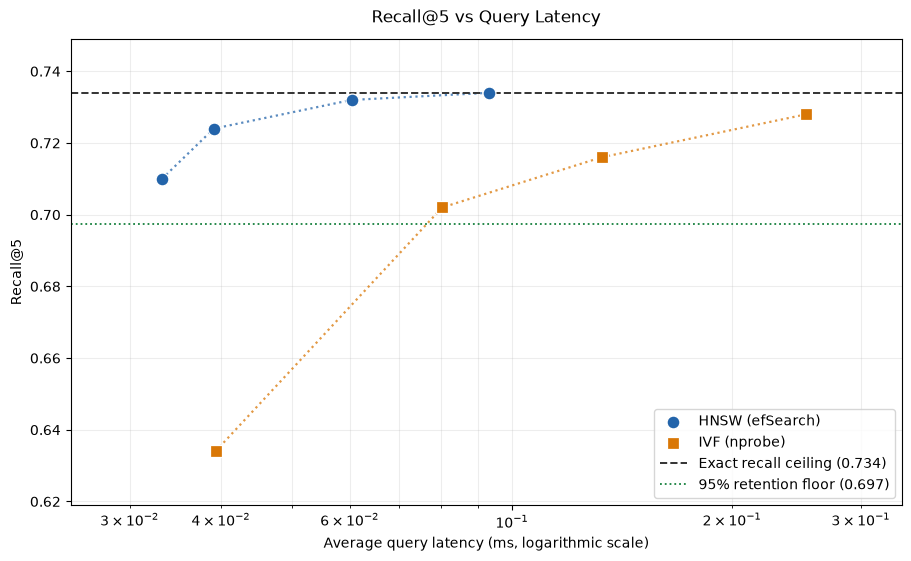

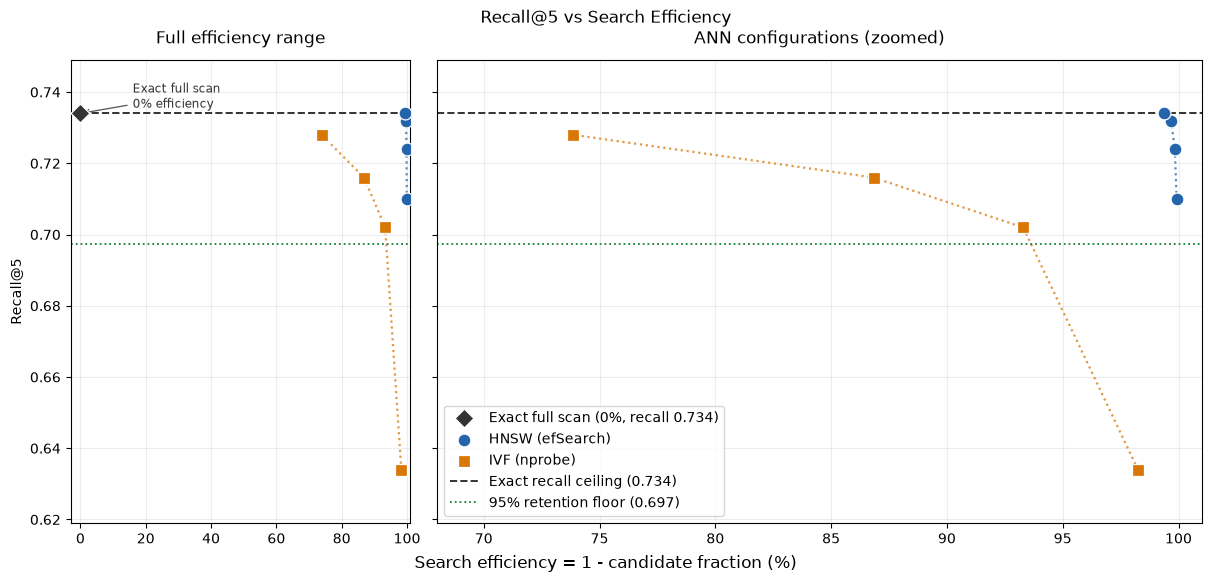

Task 6 analysis generated
  Global fastest       : HNSW {'efSearch': 8}
  Global highest recall: HNSW {'efSearch': 64}
  Best balanced        : HNSW {'efSearch': 8}
  Plots saved          : task6_recall_vs_query_latency.png, task6_recall_vs_search_efficiency.png


In [18]:
# Task 6: Quality–Latency Trade-off Summary and Required Plots
# Identify global decisions from the same live Task 5 result table.
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FormatStrFormatter


def format_config(config):
    return ", ".join(f"{key}={value}" for key, value in config.items())


required_result_columns = {
    "method",
    "config",
    "avg_recall_at_5",
    "avg_latency_s",
    "speedup_vs_exact",
    "recall_ratio",
    "candidate_vectors_examined",
    "candidate_fraction",
    "search_efficiency",
}
missing_result_columns = required_result_columns.difference(ann_results_df.columns)
assert not missing_result_columns, f"GATE FAIL: Task 5 fields missing: {sorted(missing_result_columns)}"

# Per-method reference rows support the comparison table in the written analysis.
best_hnsw = (
    ann_results_df[ann_results_df["method"] == "HNSW"]
    .sort_values(["avg_recall_at_5", "avg_latency_s"], ascending=[False, True])
    .iloc[0]
)
best_ivf = (
    ann_results_df[ann_results_df["method"] == "IVF"]
    .sort_values(["avg_recall_at_5", "avg_latency_s"], ascending=[False, True])
    .iloc[0]
)

# Global decisions required by the assignment.
fastest = ann_results_df.sort_values(
    ["avg_latency_s", "avg_recall_at_5"], ascending=[True, False]
).iloc[0]
highest_recall = ann_results_df.sort_values(
    ["avg_recall_at_5", "avg_latency_s"], ascending=[False, True]
).iloc[0]

# Best balanced = fastest configuration retaining at least 95% of exact recall.
quality_floor = 0.95 * exact_baseline_recall
balanced_candidates = ann_results_df[ann_results_df["avg_recall_at_5"] >= quality_floor]
if balanced_candidates.empty:
    balanced = highest_recall.copy()
    balanced_selection_note = "No configuration reached the 95% retention floor; highest recall was used."
else:
    balanced = balanced_candidates.sort_values(
        ["avg_latency_s", "avg_recall_at_5"], ascending=[True, False]
    ).iloc[0]
    balanced_selection_note = "Fastest configuration meeting the 95% exact-recall retention floor."

tradeoff_summary = pd.DataFrame([
    {
        "decision": "Global fastest",
        "method": fastest["method"],
        "config": fastest["config"],
        "recall_at_5": fastest["avg_recall_at_5"],
        "latency_ms": fastest["avg_latency_s"] * 1000,
        "speedup_vs_exact": fastest["speedup_vs_exact"],
        "candidate_fraction": fastest["candidate_fraction"],
    },
    {
        "decision": "Global highest recall",
        "method": highest_recall["method"],
        "config": highest_recall["config"],
        "recall_at_5": highest_recall["avg_recall_at_5"],
        "latency_ms": highest_recall["avg_latency_s"] * 1000,
        "speedup_vs_exact": highest_recall["speedup_vs_exact"],
        "candidate_fraction": highest_recall["candidate_fraction"],
    },
    {
        "decision": "Best balanced",
        "method": balanced["method"],
        "config": balanced["config"],
        "recall_at_5": balanced["avg_recall_at_5"],
        "latency_ms": balanced["avg_latency_s"] * 1000,
        "speedup_vs_exact": balanced["speedup_vs_exact"],
        "candidate_fraction": balanced["candidate_fraction"],
    },
])

plot_df = ann_results_df.copy()
plot_df["parameter_value"] = plot_df["config"].map(lambda config: next(iter(config.values())))
plot_colors = {"HNSW": "#2364AA", "IVF": "#D97706"}
plot_markers = {"HNSW": "o", "IVF": "s"}
plot_y_min = max(
    0.0,
    min(plot_df["avg_recall_at_5"].min(), exact_baseline_recall, quality_floor) - 0.015,
)
plot_y_max = min(
    1.0,
    max(plot_df["avg_recall_at_5"].max(), exact_baseline_recall) + 0.015,
)

# Plot 1: use a logarithmic latency axis because the two methods have different scales.
# Parameter values remain in the Task 5 table, keeping this figure uncluttered.
fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
for method, group in plot_df.groupby("method", sort=True):
    group = group.sort_values("parameter_value")
    ax.plot(
        group["avg_latency_s"] * 1000,
        group["avg_recall_at_5"],
        color=plot_colors[method],
        linewidth=1.6,
        linestyle=":",
        alpha=0.75,
        zorder=2,
    )
    ax.scatter(
        group["avg_latency_s"] * 1000,
        group["avg_recall_at_5"],
        color=plot_colors[method],
        marker=plot_markers[method],
        s=86,
        edgecolor="white",
        linewidth=0.9,
        label=f"{method} ({'efSearch' if method == 'HNSW' else 'nprobe'})",
        zorder=3,
    )
ax.axhline(
    exact_baseline_recall,
    color="#333333",
    linestyle="--",
    linewidth=1.4,
    label=f"Exact recall ceiling ({exact_baseline_recall:.3f})",
)
ax.axhline(
    quality_floor,
    color="#15803D",
    linestyle=":",
    linewidth=1.3,
    label=f"95% retention floor ({quality_floor:.3f})",
)
ax.set_title("Recall@5 vs Query Latency", pad=12)
ax.set_xlabel("Average query latency (ms, logarithmic scale)")
ax.set_ylabel("Recall@5")
ax.set_xscale("log")
ax.set_xlim(
    max(0.01, plot_df["avg_latency_s"].min() * 1000 * 0.75),
    plot_df["avg_latency_s"].max() * 1000 * 1.35,
)
ax.set_ylim(plot_y_min, plot_y_max)
ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
ax.grid(alpha=0.22, which="both")
ax.legend(frameon=True, loc="lower right")
latency_plot_path = os.path.join(FIGURE_DIR, "task6_recall_vs_query_latency.png")
fig.savefig(latency_plot_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

# Plot 2: use a full-range panel plus an ANN zoom so the exact 0% reference is visible
# without compressing the measured ANN configurations into an unreadable cluster.
ann_efficiency_min = plot_df["search_efficiency"].min() * 100
efficiency_axis_left = max(0, np.floor(ann_efficiency_min - 5))
efficiency_tick_start = int(np.ceil(efficiency_axis_left / 5) * 5)

fig, (ax_full, ax_zoom) = plt.subplots(
    1,
    2,
    figsize=(12, 5.5),
    sharey=True,
    gridspec_kw={"width_ratios": [1, 2.25]},
    constrained_layout=True,
)


def draw_efficiency_panel(axis, show_labels=False):
    for method, group in plot_df.groupby("method", sort=True):
        group = group.sort_values("parameter_value")
        axis.plot(
            group["search_efficiency"] * 100,
            group["avg_recall_at_5"],
            color=plot_colors[method],
            linewidth=1.6,
            linestyle=":",
            alpha=0.75,
            zorder=2,
        )
        axis.scatter(
            group["search_efficiency"] * 100,
            group["avg_recall_at_5"],
            color=plot_colors[method],
            marker=plot_markers[method],
            s=86,
            edgecolor="white",
            linewidth=0.9,
            label=(f"{method} ({'efSearch' if method == 'HNSW' else 'nprobe'})" if show_labels else "_nolegend_"),
            zorder=3,
        )
    axis.axhline(
        exact_baseline_recall,
        color="#333333",
        linestyle="--",
        linewidth=1.4,
        label=(f"Exact recall ceiling ({exact_baseline_recall:.3f})" if show_labels else "_nolegend_"),
    )
    axis.axhline(
        quality_floor,
        color="#15803D",
        linestyle=":",
        linewidth=1.3,
        label=(f"95% retention floor ({quality_floor:.3f})" if show_labels else "_nolegend_"),
    )
    axis.set_ylim(plot_y_min, plot_y_max)
    axis.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    axis.grid(alpha=0.22)


draw_efficiency_panel(ax_full)
draw_efficiency_panel(ax_zoom, show_labels=True)
exact_handle = ax_full.scatter(
    [0],
    [exact_baseline_recall],
    color="#333333",
    marker="D",
    s=92,
    edgecolor="white",
    linewidth=0.9,
    zorder=4,
    label=f"Exact full scan (0%, recall {exact_baseline_recall:.3f})",
)
ax_full.annotate(
    "Exact full scan\n0% efficiency",
    xy=(0, exact_baseline_recall),
    xytext=(16, plot_y_max - 0.006),
    arrowprops={"arrowstyle": "->", "color": "#555555", "linewidth": 0.9},
    fontsize=8.5,
    color="#333333",
    ha="left",
    va="top",
)
ax_full.set_title("Full efficiency range", pad=12)
ax_full.set_xlim(-3, 101)
ax_full.set_xticks([0, 20, 40, 60, 80, 100])
ax_zoom.set_title("ANN configurations (zoomed)", pad=12)
ax_zoom.set_xlim(efficiency_axis_left, 101)
ax_zoom.set_xticks(np.arange(efficiency_tick_start, 101, 5))
ax_full.set_ylabel("Recall@5")
ax_zoom.set_ylabel("")
handles, labels = ax_zoom.get_legend_handles_labels()
handles.insert(0, exact_handle)
labels.insert(0, f"Exact full scan (0%, recall {exact_baseline_recall:.3f})")
ax_zoom.legend(handles, labels, frameon=True, loc="lower left")
fig.suptitle("Recall@5 vs Search Efficiency", y=1.03)
fig.supxlabel("Search efficiency = 1 - candidate fraction (%)")
efficiency_plot_path = os.path.join(FIGURE_DIR, "task6_recall_vs_search_efficiency.png")
fig.savefig(efficiency_plot_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Task 6 analysis generated")
print(f"  Global fastest       : {fastest['method']} {fastest['config']}")
print(f"  Global highest recall: {highest_recall['method']} {highest_recall['config']}")
print(f"  Best balanced        : {balanced['method']} {balanced['config']}")
print(f"  Plots saved          : {os.path.basename(latency_plot_path)}, {os.path.basename(efficiency_plot_path)}")

In [19]:
# Task 6 Validation
required_decisions = {"Global fastest", "Global highest recall", "Best balanced"}
assert required_decisions.issubset(set(tradeoff_summary["decision"])), "GATE FAIL: All three global decisions are required"
assert len(tradeoff_summary) == 3, "GATE FAIL: Trade-off summary should contain three decision rows"
assert fastest["avg_latency_s"] == ann_results_df["avg_latency_s"].min(), "GATE FAIL: Fastest configuration is not global"
assert highest_recall["avg_recall_at_5"] == ann_results_df["avg_recall_at_5"].max(), "GATE FAIL: Highest-recall configuration is not global"
assert balanced["avg_recall_at_5"] >= quality_floor or balanced["avg_recall_at_5"] == highest_recall["avg_recall_at_5"], "GATE FAIL: Balanced configuration violates its documented fallback rule"
assert os.path.isfile(latency_plot_path) and os.path.getsize(latency_plot_path) > 0, "GATE FAIL: Recall-latency plot was not saved"
assert os.path.isfile(efficiency_plot_path) and os.path.getsize(efficiency_plot_path) > 0, "GATE FAIL: Recall-efficiency plot was not saved"

print("-" * 70)
print("Task 6 Validation: Required trade-off analysis completed")
print(f"  > Global fastest       : {fastest['method']} {fastest['config']}")
print(f"  > Global highest recall: {highest_recall['method']} {highest_recall['config']}")
print(f"  > Best balanced        : {balanced['method']} {balanced['config']}")
print(f"  > Quality floor        : {quality_floor:.4f} (95% of exact recall)")
print(f"  > Recall-latency plot  : saved ({os.path.getsize(latency_plot_path):,} bytes)")
print(f"  > Recall-efficiency plot: saved ({os.path.getsize(efficiency_plot_path):,} bytes)")
print("-" * 70)

----------------------------------------------------------------------
Task 6 Validation: Required trade-off analysis completed
  > Global fastest       : HNSW {'efSearch': 8}
  > Global highest recall: HNSW {'efSearch': 64}
  > Best balanced        : HNSW {'efSearch': 8}
  > Quality floor        : 0.6973 (95% of exact recall)
  > Recall-latency plot  : saved (98,609 bytes)
  > Recall-efficiency plot: saved (136,177 bytes)
----------------------------------------------------------------------


In [20]:
# Task 6: Outcome & Observations
# Render the final decisions and plot artifacts from the current Task 6 analysis.
from IPython.display import Markdown, display


def decision_config(config):
    return ", ".join(f"{key}={value}" for key, value in config.items())


balanced_retention = (
    balanced["avg_recall_at_5"] / exact_baseline_recall
    if exact_baseline_recall > 0
    else 0.0
)
large_query_recommendation = (
    f"For serving a large number of queries, select **{balanced['method']} "
    f"with `{decision_config(balanced['config'])}`** as the default balanced configuration. "
    f"It achieves Recall@5 = **{balanced['avg_recall_at_5']:.4f}** "
    f"({balanced_retention * 100:.1f}% of exact recall), average latency = "
    f"**{balanced['avg_latency_s'] * 1000:.3f} ms/query**, and "
    f"**{balanced['speedup_vs_exact']:.2f}x** speedup versus exact search."
)


decision_rows = []
for _, row in tradeoff_summary.iterrows():
    effort_label = "HNSW proxy" if row["method"] == "HNSW" else "IVF measured"
    decision_rows.append(
        f"| **{row['decision']}** | **{row['method']}** | `{decision_config(row['config'])}` | "
        f"**{row['recall_at_5']:.4f}** | {row['latency_ms']:.3f} ms | "
        f"{row['speedup_vs_exact']:.2f}x | {row['candidate_fraction'] * 100:.2f}% ({effort_label}) |"
    )

md_content = f"""
### Task 6: Outcome & Observations

The two required plots show the quality-efficiency trade-off across all eight ANN configurations. The exact search is shown as the full-scan reference at 0% search efficiency and as the Recall@5 ceiling. The efficiency figure uses a full-range panel plus an ANN zoom so both references and clustered ANN points remain readable.

| Decision | Method | Configuration | Recall@5 | Average latency | Speed relative to exact | Candidate fraction |
|---|---|---|---:|---:|---:|---:|
{chr(10).join(decision_rows)}

**Best-balanced rule:** Select the fastest ANN configuration whose recall is at least 95% of the exact baseline. The resulting retention floor is **{quality_floor:.4f}**, and the current selection is **{balanced_selection_note.lower()}**

**Large-query deployment choice:** {large_query_recommendation} If maximum recall is more important than latency, select **{highest_recall['method']} with `{decision_config(highest_recall['config'])}`**, which achieves Recall@5 = **{highest_recall['avg_recall_at_5']:.4f}** at **{highest_recall['avg_latency_s'] * 1000:.3f} ms/query**.

**Interpretation:** The fastest configuration minimizes query latency, the highest-recall configuration approaches the exact quality ceiling, and the balanced configuration applies an explicit quality requirement. HNSW is the strongest family in this run because it provides the highest measured recall with lower latency than IVF at comparable recall. IVF remains useful when partition-based indexing is preferred, but its high-`nprobe` configurations can be slower than exact search because of index overhead.

**Efficiency interpretation:** IVF candidate fractions use measured selected inverted-list sizes. HNSW candidate fractions use the `efSearch` search-work proxy because visited-node counts are not exposed by this FAISS interface. These two effort values should therefore be interpreted as indicative, not directly equivalent.

**Generated plots:** `{os.path.basename(latency_plot_path)}` and `{os.path.basename(efficiency_plot_path)}` in `{FIGURE_DIR}`.
"""

display(Markdown(md_content))


### Task 6: Outcome & Observations

The two required plots show the quality-efficiency trade-off across all eight ANN configurations. The exact search is shown as the full-scan reference at 0% search efficiency and as the Recall@5 ceiling. The efficiency figure uses a full-range panel plus an ANN zoom so both references and clustered ANN points remain readable.

| Decision | Method | Configuration | Recall@5 | Average latency | Speed relative to exact | Candidate fraction |
|---|---|---|---:|---:|---:|---:|
| **Global fastest** | **HNSW** | `efSearch=8` | **0.7100** | 0.033 ms | 2.90x | 0.08% (HNSW proxy) |
| **Global highest recall** | **HNSW** | `efSearch=64` | **0.7340** | 0.093 ms | 1.04x | 0.64% (HNSW proxy) |
| **Best balanced** | **HNSW** | `efSearch=8` | **0.7100** | 0.033 ms | 2.90x | 0.08% (HNSW proxy) |

**Best-balanced rule:** Select the fastest ANN configuration whose recall is at least 95% of the exact baseline. The resulting retention floor is **0.6973**, and the current selection is **fastest configuration meeting the 95% exact-recall retention floor.**

**Large-query deployment choice:** For serving a large number of queries, select **HNSW with `efSearch=8`** as the default balanced configuration. It achieves Recall@5 = **0.7100** (96.7% of exact recall), average latency = **0.033 ms/query**, and **2.90x** speedup versus exact search. If maximum recall is more important than latency, select **HNSW with `efSearch=64`**, which achieves Recall@5 = **0.7340** at **0.093 ms/query**.

**Interpretation:** The fastest configuration minimizes query latency, the highest-recall configuration approaches the exact quality ceiling, and the balanced configuration applies an explicit quality requirement. HNSW is the strongest family in this run because it provides the highest measured recall with lower latency than IVF at comparable recall. IVF remains useful when partition-based indexing is preferred, but its high-`nprobe` configurations can be slower than exact search because of index overhead.

**Efficiency interpretation:** IVF candidate fractions use measured selected inverted-list sizes. HNSW candidate fractions use the `efSearch` search-work proxy because visited-node counts are not exposed by this FAISS interface. These two effort values should therefore be interpreted as indicative, not directly equivalent.

**Generated plots:** `task6_recall_vs_query_latency.png` and `task6_recall_vs_search_efficiency.png` in `data/figures_sciq`.
